In [1]:
#@title Default title text
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#!ls 'drive/My Drive/local training'
import os
os.chdir('drive/My Drive/Doktora/TBC/Mescere')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [ ]:
data = pd.read_excel('kayın_mescere_parametre.xlsx')

Regresyon eğrisinin uzağında kalan değerler:
   treeID Ağaç No  Yükseklik (m)  Gövde Çapı (cm)  Canopy Çapı (m)  \
15    319    K.14         20.145               70           12.732   
17    747    K.16         20.817               75           11.051   
28    171   K.144         19.951               84           13.170   
73    859   K.217         26.315               84           11.400   

    Canopy Alanı (m2)  Canopy Hacmi (m3)  Gövde Hacmi (m3)  
15             56.494           1013.290             1.063  
17             64.644           1070.745             0.789  
28             83.546           1542.820             1.025  
73             66.033           1371.261             0.173  


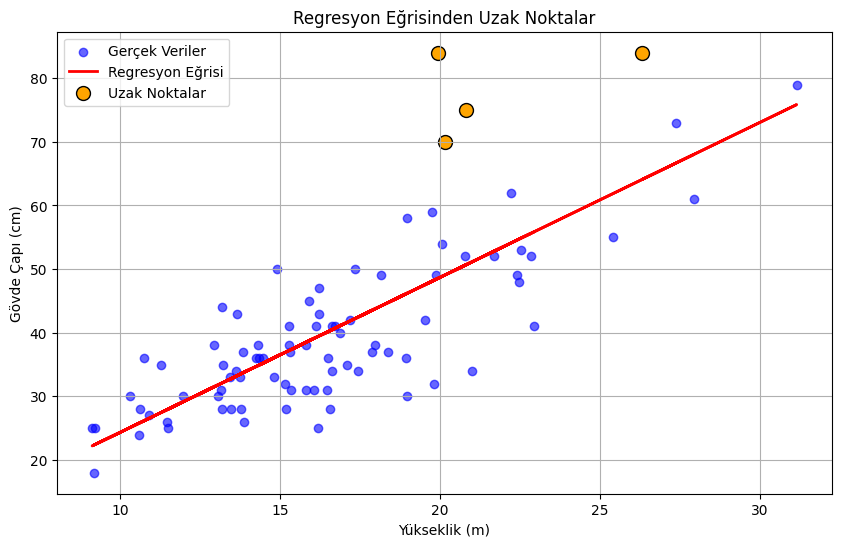

In [ ]:
# Veri setini tanımlama
X = data[['Yükseklik (m)']].values  # Bağımsız değişken
y = data['Gövde Çapı (cm)'].values  # Bağımlı değişken

# Doğrusal regresyon modeli oluşturma
model = LinearRegression()
model.fit(X, y)

# Tahmin edilen değerleri hesaplama
y_pred = model.predict(X)

# Sapmaları hesaplama
residuals = y - y_pred

# Sapmalar için eşik belirleme (Z-skoru)
z_scores = (residuals - np.mean(residuals)) / np.std(residuals)
threshold = 2  # Z-skoru için eşik (örneğin, 3)

# Uzak noktaları tespit etme
outliers = data[np.abs(z_scores) > threshold]

print("Regresyon eğrisinin uzağında kalan değerler:")
print(outliers)

# Regresyon eğrisini ve uzak noktaları görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Gerçek Veriler', color='blue', alpha=0.6)
plt.plot(X, y_pred, label='Regresyon Eğrisi', color='red', linewidth=2)
plt.scatter(X[np.abs(z_scores) > threshold], y[np.abs(z_scores) > threshold],
            label='Uzak Noktalar', color='orange', edgecolor='black', s=100)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Regresyon Eğrisinden Uzak Noktalar')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
thresholds = [1.5, 2, 3]

for threshold in thresholds:
    outliers = data[np.abs(z_scores) > threshold]
    print(f"Z-Skoru Eşiği: {threshold}")
    print(f"Uç Nokta Sayısı: {len(outliers)}")
    print(outliers)
    print("-" * 50)

Z-Skoru Eşiği: 1.5
Uç Nokta Sayısı: 10
   treeID Ağaç No  Yükseklik (m)  Gövde Çapı (cm)  Canopy Çapı (m)  \
15    319    K.14         20.145               70           12.732   
17    747    K.16         20.817               75           11.051   
28    171   K.144         19.951               84           13.170   
37   1101    K.26         14.892               50           11.296   
49    264    K.40         16.194               25            6.710   
73    859   K.217         26.315               84           11.400   
80    841   K.269         21.008               34            7.492   
81   1284   K.268         22.950               41           15.187   
83   1322   K.264         18.974               30           10.255   
85    976   K.308         19.796               32            8.967   

    Canopy Alanı (m2)  Canopy Hacmi (m3)  Gövde Hacmi (m3)  
15             56.494           1013.290             1.063  
17             64.644           1070.745             0.789  
28     

In [3]:
data = pd.read_excel('kayın-1-5.xlsx')

In [4]:
data

,treeID,Ağaç No,Yükseklik (m),Gövde Çapı (cm),Canopy Çapı (m),Canopy Alanı (m2),Canopy Hacmi (m3),Gövde Hacmi (m3)
0,824,K.5,15.915,45,9.419,41.989,536.546,0.056
1,386,K.4,17.328,50,11.068,58.070,699.226,0.217
2,979,K.6,16.608,34,6.173,13.156,240.220,0.001
3,893,K.7,12.912,38,8.816,48.059,433.054,0.126
4,575,K.8,13.062,30,8.858,45.730,437.508,0.094
...,...,...,...,...,...,...,...,...
71,996,K.215,22.464,48,6.542,17.198,378.915,0.475
72,379,K.273,22.211,62,14.968,54.748,1259.793,0.004
73,704,K272,20.057,54,11.513,27.919,933.152,0.002
74,763,K.266,18.931,36,7.134,17.841,215.155,0.807


In [5]:
# 1. Korelasyon matrisi oluşturma
selected_columns = ['Yükseklik (m)', 'Gövde Çapı (cm)', 'Canopy Çapı (m)', 'Canopy Alanı (m2)', 'Canopy Hacmi (m3)', 'Gövde Hacmi (m3)']
correlation_matrix = data[selected_columns].corr()

In [6]:
# 2. Korelasyon matrisini yazdırma
print("Korelasyon Matrisi:")
print(correlation_matrix)

Korelasyon Matrisi:
                   Yükseklik (m)  Gövde Çapı (cm)  Canopy Çapı (m)  \
Yükseklik (m)           1.000000         0.869685         0.314412   
Gövde Çapı (cm)         0.869685         1.000000         0.469164   
Canopy Çapı (m)         0.314412         0.469164         1.000000   
Canopy Alanı (m2)       0.230443         0.413534         0.844612   
Canopy Hacmi (m3)       0.682823         0.755895         0.803305   
Gövde Hacmi (m3)        0.493560         0.485515         0.098462   

                   Canopy Alanı (m2)  Canopy Hacmi (m3)  Gövde Hacmi (m3)  
Yükseklik (m)               0.230443           0.682823          0.493560  
Gövde Çapı (cm)             0.413534           0.755895          0.485515  
Canopy Çapı (m)             0.844612           0.803305          0.098462  
Canopy Alanı (m2)           1.000000           0.714712          0.153707  
Canopy Hacmi (m3)           0.714712           1.000000          0.145170  
Gövde Hacmi (m3)            0.153

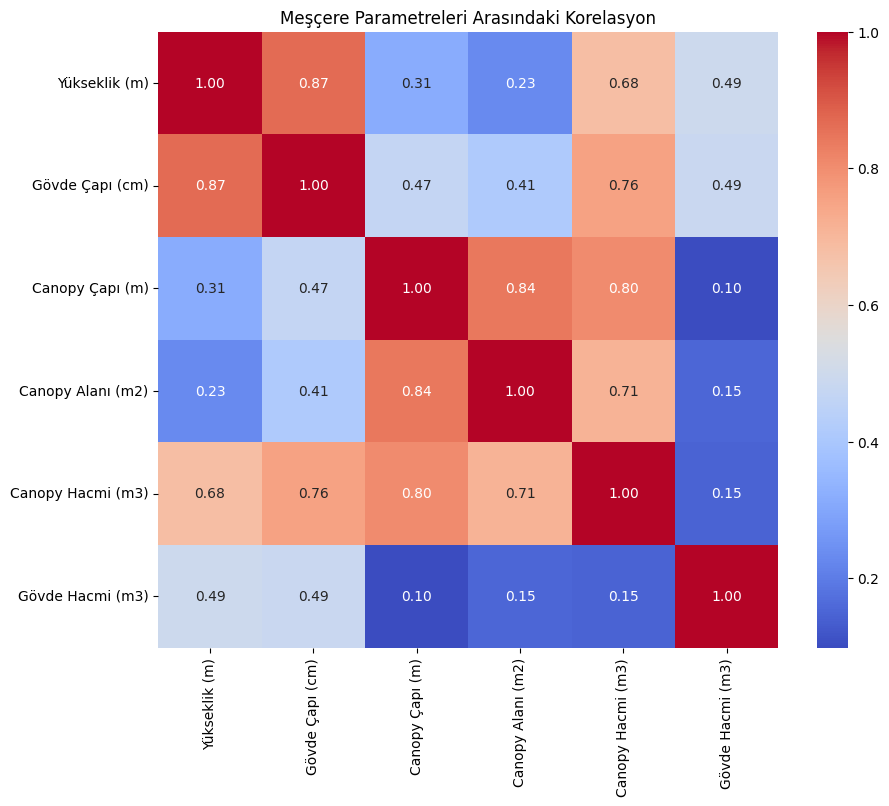

In [7]:
# 3. Korelasyon matrisini görselleştirme (Isı haritası)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Meşçere Parametreleri Arasındaki Korelasyon')
plt.show()

Regresyon Formülü: Gövde Çapı (cm) = 2.28 * Yükseklik (m) + 2.12
Doğrusal Regresyon Modeli Performansı:
R²: 0.76
MAE: 4.54 (Ortalama Mutlak Hata)
MSE: 31.38 (Ortalama Kare Hata)

Yükseklik 20 metre için tahmini Gövde Çapı: 47.63 cm


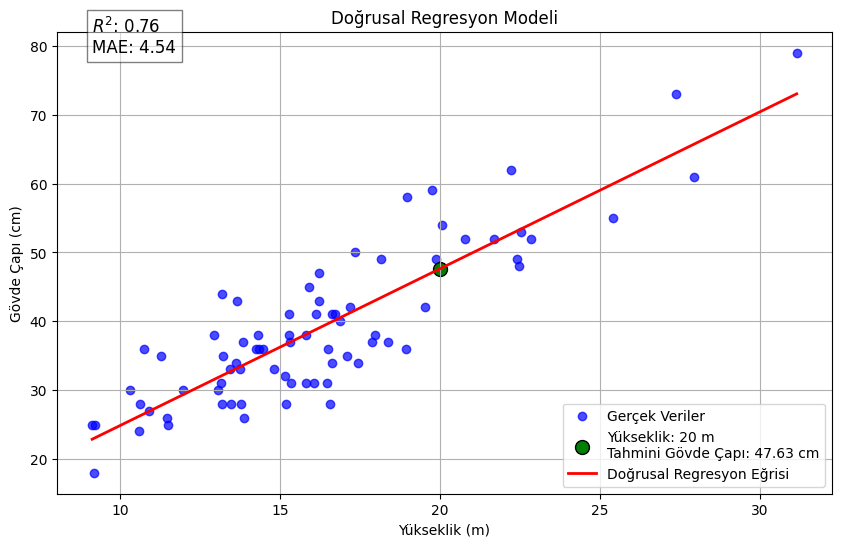

In [ ]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Model tanımlama ve eğitme
lr_model = LinearRegression()
lr_model.fit(X, y)

# Modelin katsayılarını ve kesişimini öğrenme
a = lr_model.coef_[0]  # Katsayı
b = lr_model.intercept_  # Kesişim noktası
print(f"Regresyon Formülü: Gövde Çapı (cm) = {a:.2f} * Yükseklik (m) + {b:.2f}")

# Tahminler
y_pred_lr = lr_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_lr)
mae = mean_absolute_error(y, y_pred_lr)
mse = mean_squared_error(y, y_pred_lr)

# Model performansını yazdırma
print(f"Doğrusal Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 20  # Örnek yükseklik değeri
predicted_diameter = lr_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve doğrusal regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = lr_model.predict(X_curve)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 20 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='Doğrusal Regresyon Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Doğrusal Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

Polinomsal Regresyon Formülü: Gövde Çapı (cm) = 0.03 * Yükseklik² + 1.10 * Yükseklik + 12.19
Polinomsal Regresyon Modeli Performansı (Derece 2):
R²: 0.76
MAE: 4.46 (Ortalama Mutlak Hata)
MSE: 30.53 (Ortalama Kare Hata)

Yükseklik 20 metre için tahmini Gövde Çapı: 46.96 cm


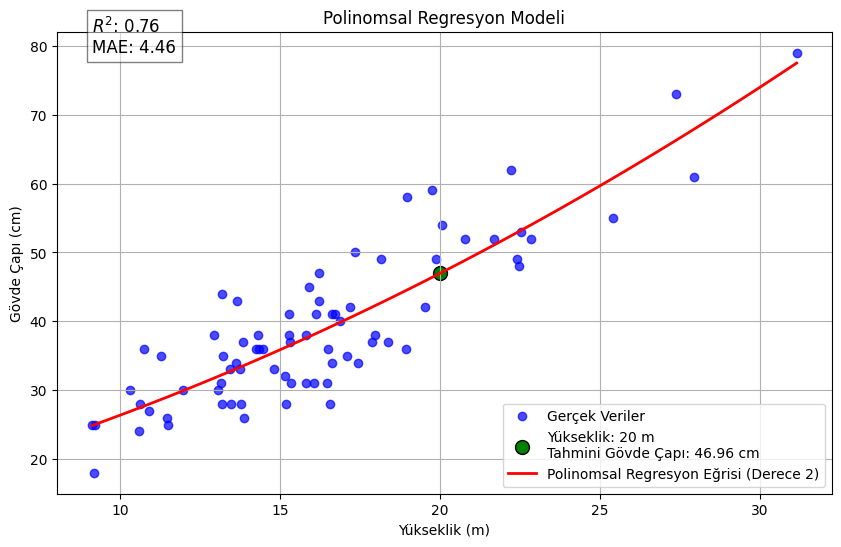

In [ ]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Polinom özellikler oluşturma (derece 2)
degree = 2
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)

# Model tanımlama ve eğitme
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Polinomsal regresyon formülü öğrenme
coefficients = poly_model.coef_
intercept = poly_model.intercept_
formula = f"Gövde Çapı (cm) = {coefficients[2]:.2f} * Yükseklik² + {coefficients[1]:.2f} * Yükseklik + {intercept:.2f}"
print(f"Polinomsal Regresyon Formülü: {formula}")

# Tahminler
y_pred_poly = poly_model.predict(X_poly)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_poly)
mae = mean_absolute_error(y, y_pred_poly)
mse = mean_squared_error(y, y_pred_poly)

# Model performansını yazdırma
print(f"Polinomsal Regresyon Modeli Performansı (Derece {degree}):")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 20  # Örnek yükseklik değeri
user_height_poly = poly.transform([[user_height]])
predicted_diameter = poly_model.predict(user_height_poly)
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve polinomsal regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_curve_poly = poly.transform(X_curve)
y_curve = poly_model.predict(X_curve_poly)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 20 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label=f'Polinomsal Regresyon Eğrisi (Derece {degree})', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Polinomsal Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

Logaritmik Regresyon Formülü: Gövde Çapı (cm) = 37.17 * ln(Yükseklik) + -63.29
Logaritmik Regresyon Modeli Performansı:
R²: 0.71
MAE: 4.79 (Ortalama Mutlak Hata)
MSE: 37.76 (Ortalama Kare Hata)

Yükseklik 20 metre için tahmini Gövde Çapı: 48.06 cm


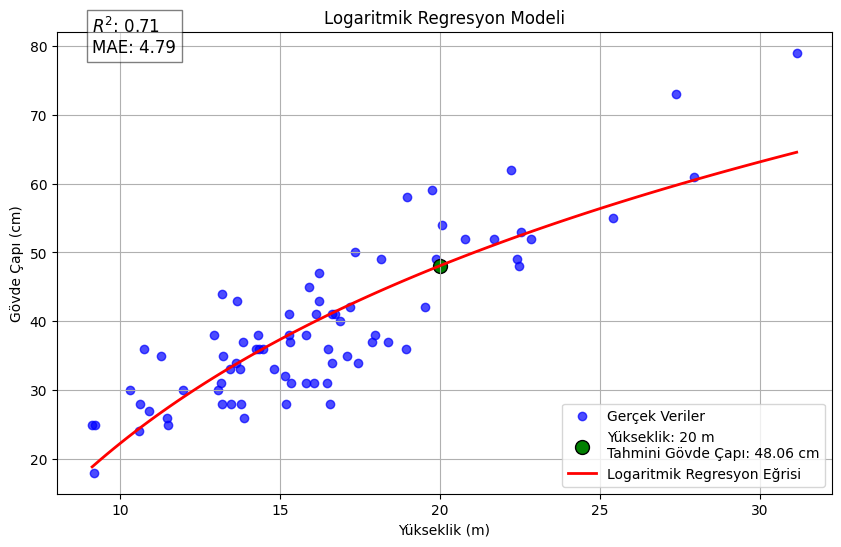

In [ ]:
# Bağımsız ve bağımlı değişkenleri ayırma (logaritmik dönüşüm)
X = np.log(data['Yükseklik (m)'].values).reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Model tanımlama ve eğitme
log_model = LinearRegression()
log_model.fit(X, y)

# Logaritmik regresyon formülü öğrenme
a = log_model.coef_[0]  # Katsayı
b = log_model.intercept_  # Kesişim noktası
formula = f"Gövde Çapı (cm) = {a:.2f} * ln(Yükseklik) + {b:.2f}"
print(f"Logaritmik Regresyon Formülü: {formula}")

# Tahminler
y_pred_log = log_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_log)
mae = mean_absolute_error(y, y_pred_log)
mse = mean_squared_error(y, y_pred_log)

# Model performansını yazdırma
print(f"Logaritmik Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 20  # Örnek yükseklik değeri
user_log_height = np.log(user_height).reshape(1, -1)
predicted_diameter = log_model.predict(user_log_height)
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve logaritmik regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(data['Yükseklik (m)'], y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(data['Yükseklik (m)'].min(), data['Yükseklik (m)'].max(), 100).reshape(-1, 1)
X_curve_log = np.log(X_curve)
y_curve = log_model.predict(X_curve_log)

# R² değerini grafiğin üzerine ekleme
plt.text(x=data['Yükseklik (m)'].min(), y=max(y), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 20 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='Logaritmik Regresyon Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Logaritmik Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

Destek Vektör Regresyon Modeli Performansı:
R²: 0.77
MAE: 4.19 (Ortalama Mutlak Hata)
MSE: 29.06 (Ortalama Kare Hata)

Yükseklik 20 metre için tahmini Gövde Çapı: 49.44 cm


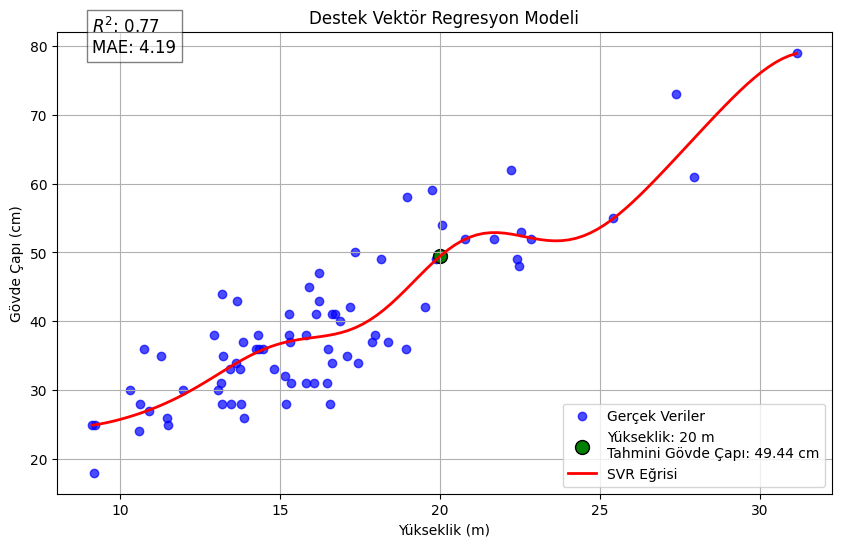

In [ ]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Destek Vektör Regresyon modeli tanımlama ve eğitme
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X, y)

# Tahminler
y_pred_svr = svr_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_svr)
mae = mean_absolute_error(y, y_pred_svr)
mse = mean_squared_error(y, y_pred_svr)

# Model performansını yazdırma
print(f"Destek Vektör Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 20  # Örnek yükseklik değeri
predicted_diameter = svr_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve SVR eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = svr_model.predict(X_curve)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=max(y), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 20 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='SVR Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Destek Vektör Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

RandomForest Regressor Modeli Performansı:
R²: 0.94
MAE: 2.22 (Ortalama Mutlak Hata)
MSE: 7.75 (Ortalama Kare Hata)

Yükseklik 27.388 metre için tahmini Gövde Çapı: 68.68 cm


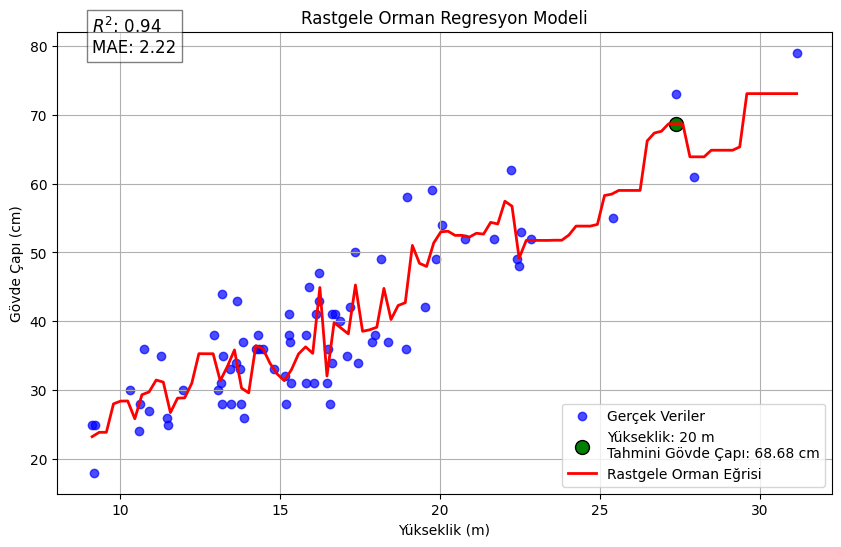

In [31]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Model tanımlama ve eğitme
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Tahminler
y_pred_rf = rf_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_rf)
mae = mean_absolute_error(y, y_pred_rf)
mse = mean_squared_error(y, y_pred_rf)

# Model performansını yazdırma
print(f"RandomForest Regressor Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 27.388  # Örnek yükseklik değeri
predicted_diameter = rf_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve RandomForest regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = rf_model.predict(X_curve)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 20 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='Rastgele Orman Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Rastgele Orman Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

XGBoost Regresyon Modeli Performansı:
R²: 0.92
MAE: 2.57 (Ortalama Mutlak Hata)
MSE: 10.53 (Ortalama Kare Hata)

Yükseklik 27.388 metre için tahmini Gövde Çapı: 70.72 cm


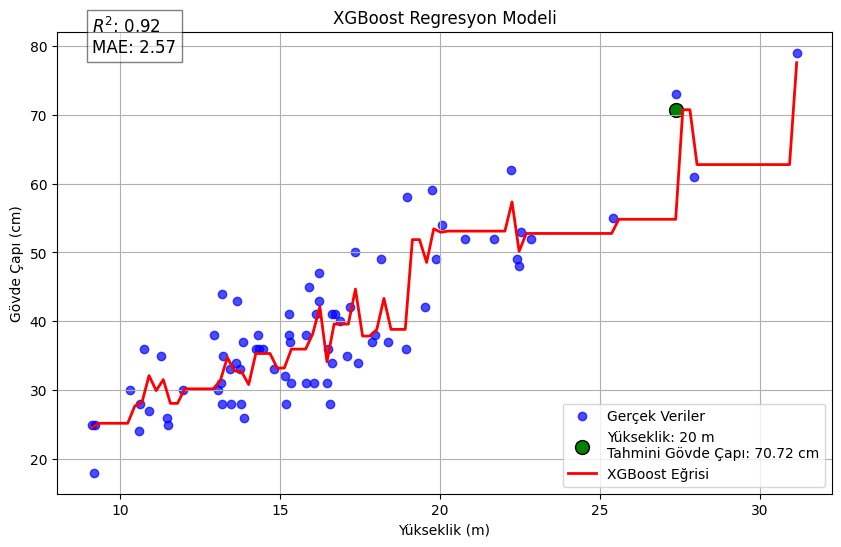

In [26]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# XGBoost Regresyon modeli tanımlama ve eğitme
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X, y)

# Tahminler
y_pred_xgb = xgb_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_xgb)
mae = mean_absolute_error(y, y_pred_xgb)
mse = mean_squared_error(y, y_pred_xgb)

# Model performansını yazdırma
print(f"XGBoost Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 27.388  # Örnek yükseklik değeri
predicted_diameter = xgb_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve XGBoost eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = xgb_model.predict(X_curve)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=max(y), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 20 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='XGBoost Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('XGBoost Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

<ipython-input-25-ceeed1eee5f3>:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X, y], labels=['Yükseklik (m)', 'Gövde Çapı (cm)'])
<ipython-input-25-ceeed1eee5f3>:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X.ravel(), y], labels=['Yükseklik (m)', 'Gövde Çapı (cm)'])  # Flatten X using ravel()


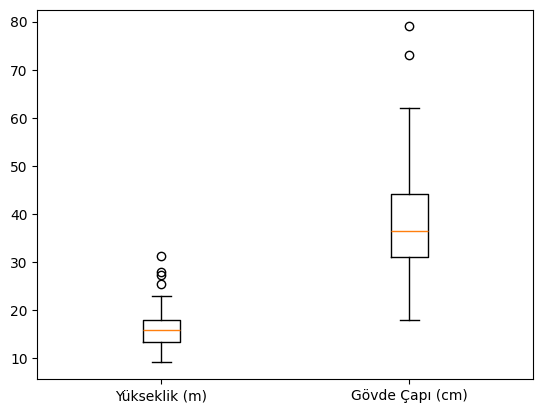

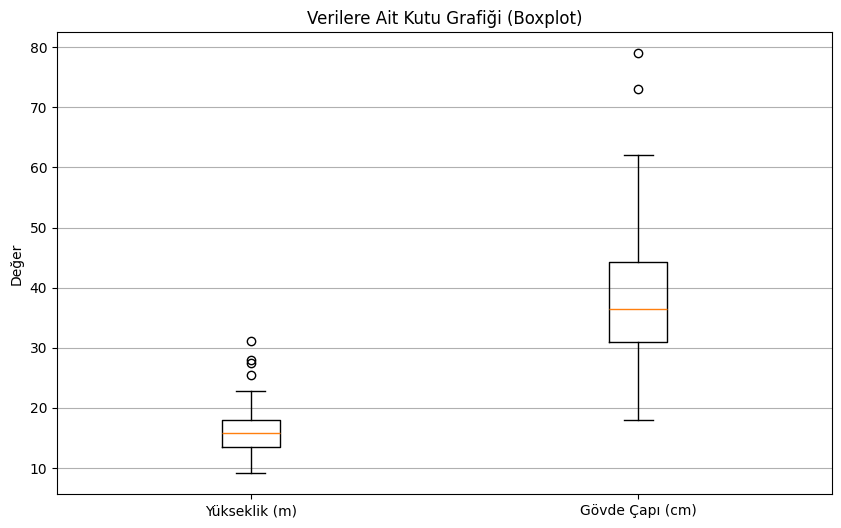

In [ ]:
X = data['Yükseklik (m)'].values

plt.boxplot([X, y], labels=['Yükseklik (m)', 'Gövde Çapı (cm)'])

plt.figure(figsize=(10, 6))
plt.boxplot([X.ravel(), y], labels=['Yükseklik (m)', 'Gövde Çapı (cm)'])  # Flatten X using ravel()
plt.title('Verilere Ait Kutu Grafiği (Boxplot)')
plt.ylabel('Değer')
plt.grid(axis='y')
plt.show()


In [ ]:
# Uç değerleri bulmak için alt ve üst sınırları hesaplama
Q1 = data['Yükseklik (m)'].quantile(0.25)  # 1. Çeyrek
Q3 = data['Yükseklik (m)'].quantile(0.75)  # 3. Çeyrek
IQR = Q3 - Q1  # Çeyrekler arası aralık

# Alt ve üst sınırlar
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Yükseklik için uç değerleri kaldırma
data_no_outliers = data[(data['Yükseklik (m)'] >= lower_bound) & (data['Yükseklik (m)'] <= upper_bound)]

# Aynı işlemi gövde çapı için yapabilirsiniz
Q1_diameter = data['Gövde Çapı (cm)'].quantile(0.25)
Q3_diameter = data['Gövde Çapı (cm)'].quantile(0.75)
IQR_diameter = Q3_diameter - Q1_diameter

lower_bound_diameter = Q1_diameter - 1.5 * IQR_diameter
upper_bound_diameter = Q3_diameter + 1.5 * IQR_diameter

data_no_outliers = data_no_outliers[
    (data_no_outliers['Gövde Çapı (cm)'] >= lower_bound_diameter) &
    (data_no_outliers['Gövde Çapı (cm)'] <= upper_bound_diameter)
]


<ipython-input-30-39f692ecab9d>:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


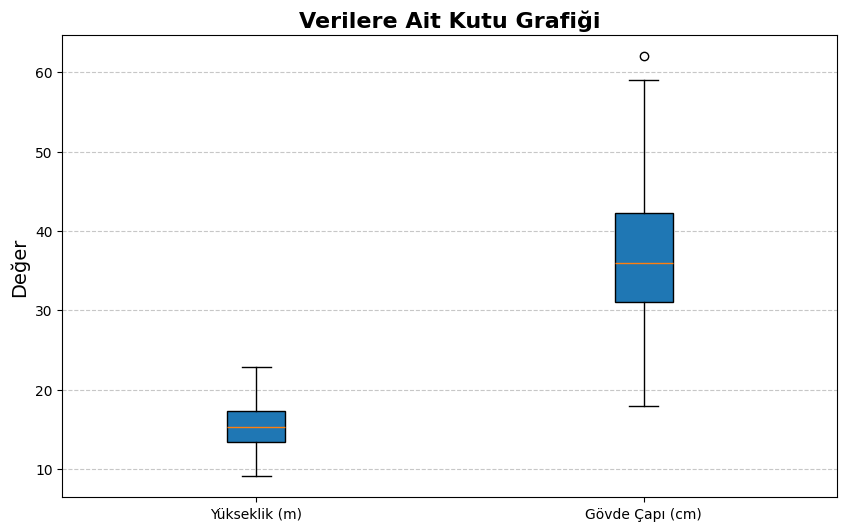

In [ ]:
# Uç değerleri kaldırılmış veriyle kutu grafiği
plt.figure(figsize=(10, 6))
plt.boxplot(
    [data_no_outliers['Yükseklik (m)'], data_no_outliers['Gövde Çapı (cm)']],
    labels=['Yükseklik (m)', 'Gövde Çapı (cm)'],
    patch_artist=True
)

# Grafik detayları
plt.title('Verilere Ait Kutu Grafiği', fontsize=16, fontweight='bold')
plt.ylabel('Değer', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()